<a href="https://colab.research.google.com/github/pikey-msc/AprendizMaquina/blob/main/2026-2/MLG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Antecedente: ¿Por qué usar Modelos Lineales Generalizados (MLG o GLM)?**

Los **Modelos Lineales Generalizados (MLG)** son una extensión de la regresión lineal que permiten modelar relaciones más complejas entre variables. Por ejemplo, en un estudio de predicción de reclamaciones de seguros, una regresión
lineal podría producir valores negativos, lo que no tiene sentido. Un MLG con distribución de Poisson o Gamma permite modelar adecuadamente la naturaleza de estos datos y garantizar predicciones válidas. Algunas razones clave para utilizarlos son:

- **Mayor flexibilidad:** Mientras que la regresión lineal solo modela relaciones lineales, los MLG pueden modelar relaciones más generales a través de funciones de enlace.
- **Adaptabilidad a diferentes distribuciones:** Permiten modelar variables con diferentes distribuciones, como:
  - **Bernoulli:** Para datos binarios.
  - **Poisson:** Para datos de conteo.
  - **Gamma o Inversa Gaussiana:** Para valores positivos con colas pesadas.
  - **Beta:** Para proporciones en el intervalo (0,1).
- **Varianza no constante:** La regresión lineal asume **homocedasticidad** (varianza constante del error), pero los MLG permiten que la varianza dependa de la media.

Matemáticamente, un **Modelo Lineal Generalizado** se expresa como:

$$ g(E(Y)) = X\beta  \iff E(Y) = g^{-1}(X\beta) $$

donde:

- $ E(Y) $ es la **esperanza** de la variable dependiente.
- $ g(\cdot) $ es la **función de enlace**, que transforma la relación entre la media y los predictores.
- $ X\beta $ es la combinación lineal de los predictores.

## **¿Cómo se diferencian de la Regresión Lineal Múltiple?**
La **Regresión Lineal Múltiple (RLM)** tiene la forma:

$$ E(Y) = X\beta + \epsilon $$

donde $ \epsilon \sim N(0, \sigma^2) $, es decir, el error sigue una distribución normal con varianza constante. Sin embargo, este modelo presenta problemas cuando:

- **Los datos no son normales:** Si $ Y $ no sigue una distribución normal, los supuestos de la regresión lineal pueden no ser válidos.
- **La relación entre Y y X no es lineal:** Si la variable dependiente sigue una relación no lineal con los predictores, una transformación mediante una función de enlace es más apropiada.
- **La varianza del error no es constante:** Si la varianza varía con la media, es preferible usar un modelo que lo capture adecuadamente, como los MLG.

En conclusión, los MLG permiten generalizar la regresión lineal para manejar una gama más amplia de tipos de datos y relaciones funcionales, lo que los convierte en una herramienta poderosa en estadística y aprendizaje de máquina. Se aplican ampliamente en sectores como seguros (para modelar la siniestralidad), salud (para analizar el riesgo de enfermedades), y finanzas (para predecir la probabilidad de impago en créditos).

---


## ¿Por qué no usar Regresión Lineal Múltiple en su lugar?
La regresión lineal múltiple (RLM) es una opción válida cuando la variable dependiente es continua y satisface los supuestos de normalidad y homocedasticidad. Sin embargo, cuando la variable dependiente no sigue una distribución normal o la relación entre las variables no es lineal, los MLG son más adecuados.

Para determinar si un MLG es más adecuado que una regresión lineal, se deben analizar los siguientes aspectos:

Distribución de la variable dependiente:

Para decidir entre regresión lineal y un modelo MLG, hay que analizar la **distribución de la variable dependiente**:

| **Tipo de variable Y**            | **Distribución**            | **Modelo MLG**                |
|------------------------------------|-----------------------------|-------------------------------|
| **Binaria $\{0, 1\}$**                  | Bernoulli                   | Regresión Logística  o Probit        |
| **Conteos (0,1,2...)**             | Poisson                     | Regresión de Poisson         |
| **Positiva (valores continuos)**   | Gamma o Inversa Gaussiana   | Regresión Gamma o IG         |
| **Proporciones (0 a 1)**           | Beta                        | Regresión Beta               |
| **Con colas pesadas**              | Tweedie                     | Regresión Tweedie            |




Varianza de los residuos: \\
Si la varianza es constante → Regresión Lineal. \\
Si la varianza cambia con la media → MLG. \\



Conclusión: 🚀Este ejemplo muestra por qué los MLG son necesarios cuando la variable dependiente no es continua y normal. Además, si la variable dependiente tuviera valores positivos con colas pesadas, un modelo Gamma podría ser más adecuado. Para datos de proporciones en el intervalo (0,1), la regresión Beta sería una mejor opción. En este caso, la regresión lineal falla al predecir valores negativos y no captura bien la relación entre $ X $ y $ Y $, mientras que el modelo de Poisson se ajusta de manera más adecuada.

## Ejemplo de código para ver distribución de variables

## Complementar este ejemplito

In [ ]:
import scipy.stats as stats

def determinar_distribucion(Y):
    print("Prueba de Normalidad (Shapiro-Wilk):")
    stat, p = stats.shapiro(Y)
    print(f"Estadístico={stat}, p-valor={p}")
    if p < 0.05:
        print("Los datos no siguen una distribución normal.")
    else:
        print("Los datos podrían seguir una distribución normal.")

    print("\nPrueba de Poisson (Varianza ≈ Media):")
    media = np.mean(Y)
    varianza = np.var(Y)
    print(f"Media={media}, Varianza={varianza}")
    if abs(media - varianza) < 0.1 * media:
        print("Los datos podrían seguir una distribución de Poisson.")

    print("\nPrueba de Gamma (solo para valores positivos):")
    if np.all(Y > 0):
        shape, loc, scale = stats.gamma.fit(Y)
        print(f"Parámetro shape={shape}, scale={scale}")
    else:
        print("Los datos no pueden ser modelados con Gamma.")

# Generar datos de ejemplo
Y_test = np.random.poisson(3, 100)
determinar_distribucion(Y_test)


Prueba de Normalidad (Shapiro-Wilk):
Estadístico=0.9486831771172384, p-valor=0.0006800910168486984
Los datos no siguen una distribución normal.

Prueba de Poisson (Varianza ≈ Media):
Media=2.98, Varianza=3.2596
Los datos podrían seguir una distribución de Poisson.

Prueba de Gamma (solo para valores positivos):
Los datos no pueden ser modelados con Gamma.


# **Detalle de cada función de vínculo en Modelos Lineales Generalizados (MLG)**

En los Modelos Lineales Generalizados (MLG), la **función de vínculo** $ g(\cdot) $ es crucial, ya que establece la relación entre la esperanza de la variable dependiente $ E(Y) $ y la combinación lineal de los predictores:

$$ g(E(Y)) = X\beta $$

A continuación, se detallan las funciones de vínculo más comunes:

| **Función de Vínculo** | **Definición Matemática** | **Distribución Asociada** | **Dominio de la Variable** | **Uso Común** |
|-------------------------|----------------------------------|---------------------------|---------------------|----------------|
| **Identidad** | $$ g(μ) = μ $$ | Normal | $$ (-\infty, \infty) $$ | Regresión Lineal |
| **Logit** | $$ g(μ) = \log\left(\frac{μ}{1 - μ}\right) $$ | Bernoulli | $$ \{0,1\}  $$ | Regresión Logística |
| **Probit** | $$ g(μ) = \Phi^{-1}(μ) $$ | Bernoulli | $$ \{0,1\} $$ | Modelos Probit |
| **Logarítmica** | $$ g(μ) = \log(μ) $$ | Poisson | $$ \{0,1,\ldots, \infty\} $$ | Modelos de Conteo |
| **Recíproca** | $$ g(μ) = \frac{1}{μ} $$ | Gamma o Inversa Gaussiana | $$ (0,\infty) $$ | Modelos para datos positivos |
| **Log-Cauchy** | $$ g(μ) = \log\left(\frac{μ}{1 + μ}\right) $$ | Beta | $$ (0,1) $$ | Regresión Beta |
| **Potencia** | $$ g(μ) = μ^p $$ | Tweedie | $$ (0,\infty) $$ | Modelos con colas pesadas |

Ejemplo en Python: Comparación de funciones de vínculo

Vamos a ilustrar cómo distintas funciones de vínculo afectan las predicciones en un MLG con datos de conte


## **Ejemplo en Python: Comparación de Regresión Lineal y MLG (Poisson)**
Vamos a comparar la **regresión lineal** con un **MLG de Poisson** en un problema donde la variable dependiente es de conteo. La distribución de Poisson es apropiada en este caso porque modela datos de conteo donde la media y la varianza son aproximadamente iguales. En contraste, si los datos presentaran sobre-dispersón (varianza mayor que la media), una distribución Binomial Negativa podría ser más adecuada.

Ejemplo en Python: Vamos a comparar una regresión lineal y un modelo MLG en un caso donde la variable respuesta es binaria $\{0,1\}$. La regresión lineal intentará ajustarse a esta variable, lo que dará resultados poco realistas.

Optimization terminated successfully.
         Current function value: 0.579560
         Iterations 6
Resultados de Regresión Lineal:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.203
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     24.95
Date:                Wed, 05 Mar 2025   Prob (F-statistic):           2.56e-06
Time:                        02:39:13   Log-Likelihood:                -61.217
No. Observations:                 100   AIC:                             126.4
Df Residuals:                      98   BIC:                             131.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.97

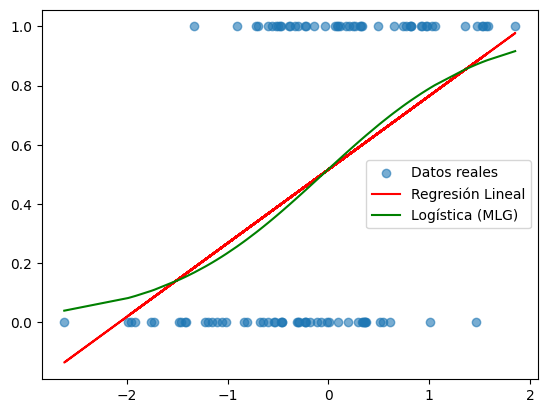

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression

# Simulamos datos
np.random.seed(42)
X = np.random.normal(0, 1, 100)
p = 1 / (1 + np.exp(-1.5 * X))  # Probabilidad basada en logística
Y = (np.random.rand(100) < p).astype(int)  # Generamos valores binarios

# Ajuste de Regresión Lineal
X_const = sm.add_constant(X)  # Agregamos intercepto
modelo_rl = sm.OLS(Y, X_const).fit()

# Ajuste de Regresión Logística (MLG)
modelo_glm = sm.Logit(Y, X_const).fit()

# Resultados
print("Resultados de Regresión Lineal:")
print(modelo_rl.summary())

print("\nResultados de Regresión Logística:")
print(modelo_glm.summary())

# Gráfico de predicciones
plt.scatter(X, Y, label="Datos reales", alpha=0.6)
plt.plot(X, modelo_rl.predict(X_const), label="Regresión Lineal", color='red')
plt.plot(np.sort(X), modelo_glm.predict(X_const)[np.argsort(X)], label="Logística (MLG)", color='green')
plt.legend()
plt.show()

Interpretación:

La regresión lineal produce valores fuera del rango
$[0,1]$, lo cual no tiene sentido para variables binarias.
La regresión logística (MLG) usa la función logística, asegurando predicciones entre 0 y 1.

In [ ]:
?sm.GLM

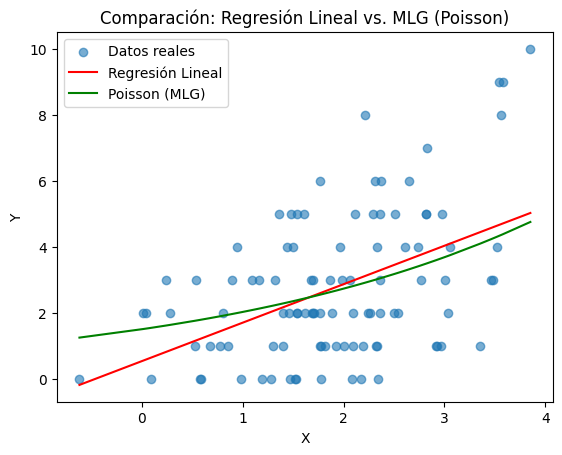

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import PoissonRegressor

# Simulación de datos de conteo
np.random.seed(42)
X = np.random.normal(2, 1, 100)  # Variable independiente
Y = np.random.poisson(np.exp(0.5 * X))  # Variable dependiente con distribución Poisson

# Ajuste de Regresión Lineal
X_const = sm.add_constant(X)  # Agregamos intercepto
modelo_rl = sm.OLS(Y, X_const).fit()

# Ajuste de MLG con Poisson
modelo_glm_poisson = PoissonRegressor().fit(X.reshape(-1, 1), Y)

# Predicciones
X_sorted = np.sort(X)
pred_rl = modelo_rl.predict(sm.add_constant(X_sorted))
pred_poisson = modelo_glm_poisson.predict(X_sorted.reshape(-1, 1))

# Graficamos los resultados
plt.scatter(X, Y, label="Datos reales", alpha=0.6)
plt.plot(X_sorted, pred_rl, label="Regresión Lineal", color='red')
plt.plot(X_sorted, pred_poisson, label="Poisson (MLG)", color='green')
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Comparación: Regresión Lineal vs. MLG (Poisson)")
plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The identity link function does not respect the domain of the Poisson family.
  warnings.warn((f"The {type(family.link).__name__} link function "


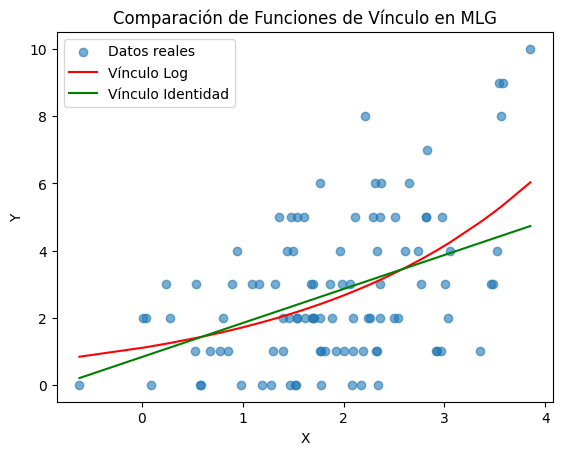

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Simulamos datos de conteo
np.random.seed(42)
X = np.random.normal(2, 1, 100)
Y = np.random.poisson(np.exp(0.5 * X))  # Relación exponencial

# Ajuste de MLG con función de vínculo logarítmica
modelo_glm_log = sm.GLM(Y, sm.add_constant(X), family=sm.families.Poisson(link=sm.families.links.log())).fit()

# Ajuste con función identidad (equivalente a regresión lineal en Poisson)
modelo_glm_id = sm.GLM(Y, sm.add_constant(X), family=sm.families.Poisson(link=sm.families.links.identity())).fit()

# Predicciones
X_sorted = np.sort(X)
pred_log = modelo_glm_log.predict(sm.add_constant(X_sorted))
pred_id = modelo_glm_id.predict(sm.add_constant(X_sorted))

# Graficamos los resultados
plt.scatter(X, Y, label="Datos reales", alpha=0.6)
plt.plot(X_sorted, pred_log, label="Vínculo Log", color='red')
plt.plot(X_sorted, pred_id, label="Vínculo Identidad", color='green')
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Comparación de Funciones de Vínculo en MLG")
plt.show()

## **Interpretación de los Resultados**
### 📌 **1. Regresión Lineal**
✔ Modela la relación entre $X$ y $Y$ con una función lineal.  
✔ Puede predecir valores **negativos**, lo cual **no tiene sentido** para conteos.  
✔ Asume **varianza constante**, lo que **no es realista** para variables de conteo.  

### 📌 **2. Regresión de Poisson (MLG)**
✔ Usa una **función exponencial**, asegurando que todas las predicciones sean **positivas**.  
✔ Modela la varianza en función de la media, capturando la **naturaleza heterocedástica** de los datos. En un modelo de Poisson, la varianza es igual a la media ($ Var(Y) = E(Y) $), lo que implica que a medida que aumenta la media de la variable dependiente, la dispersión de los datos también lo hace. Esto contrasta con la regresión lineal, que asume una varianza constante independientemente de la media.  
✔ Se adapta mejor a la forma de los datos, ajustando mejor las predicciones.


Interpretación:

* La función logarítmica evita predicciones negativas y respeta la naturaleza de los datos de conteo.
* La función identidad no respeta la restricción de positividad, lo que puede llevar a predicciones inválidas.

#Ajuste de parámetros en Modelos Lineales Generalizados (MLG)**

El ajuste de los coeficientes $ \beta $ en un MLG se realiza mediante la **Estimación por Máxima Verosimilitud (MLE)** en lugar de Mínimos Cuadrados Ordinarios (MCO). Esto se debe a que la función de verosimilitud cambia según la distribución de la variable dependiente.

## **Función de Máxima Verosimilitud en MLG**
### **1. Regresión Logística (Distribución Bernoulli)**
La función de verosimilitud para la regresión logística es:

$$ L(\beta) = \prod_{i=1}^{n} p_i^{y_i} (1 - p_i)^{(1 - y_i)} $$

donde:
- $ p_i = \frac{e^{X_i \beta}}{1 + e^{X_i \beta}} = \frac{1}{1 + e^{-X_i \beta}} $ es la probabilidad del evento.
- $ y_i $ toma valores 0 o 1.

La log-verosimilitud se obtiene aplicando logaritmo:

$$ \log L(\beta) = \sum_{i=1}^{n} \left[ y_i \log p_i + (1 - y_i) \log(1 - p_i) \right] $$

### **2. Regresión de Poisson**
La función de verosimilitud para un modelo de Poisson es:

$$ L(\beta) = \prod_{i=1}^{n} \frac{e^{-\lambda_i} \lambda_i^{y_i}}{y_i!} $$

donde $ \lambda_i = e^{X_i \beta} $ es la media de la distribución.

La log-verosimilitud es:

$$ \log L(\beta) = \sum_{i=1}^{n} \left[ y_i \log \lambda_i - \lambda_i - \log(y_i!) \right] $$

### **3. Regresión Beta**
Para datos en $ (0,1) $, se usa la distribución Beta con densidad:

$$ f(y | \alpha, \beta) = \frac{y^{\alpha - 1} (1 - y)^{\beta - 1}}{B(\alpha, \beta)} $$

donde $ B(\alpha, \beta) $ es la función Beta.

La log-verosimilitud es:

$$ \log L(\beta) = \sum_{i=1}^{n} \left[ (\alpha - 1) \log y_i + (\beta - 1) \log(1 - y_i) - \log B(\alpha, \beta) \right] $$

---

## **Algoritmo de Máxima Verosimilitud**
El método más común para estimar $ \beta $ es el **método iterativo de Newton-Raphson**:

1. Se define la función de log-verosimilitud $ \ell(\beta) $.
2. Se calcula el gradiente (primera derivada) $ \nabla \ell(\beta) $.
3. Se obtiene la matriz Hessiana (segunda derivada) $ H(\beta) $.
4. Se actualiza el estimador en cada iteración:

   $$ \beta^{(t+1)} = \beta^{(t)} - H^{-1}(\beta) \nabla \ell(\beta) $$

A continuación, implementamos el cálculo paso por paso de la estimación por máxima verosimilitud para la regresión de Poisson utilizando el método de Newton-Raphson:


In [ ]:
import numpy as np

def poisson_log_likelihood(beta, X, Y):
    mu = np.exp(X @ beta)
    return -np.sum(Y * np.log(mu) - mu)

def poisson_gradient(beta, X, Y):
    mu = np.exp(X @ beta)
    return X.T @ (mu - Y)

def poisson_hessian(beta, X):
    mu = np.exp(X @ beta)
    W = np.diag(mu)
    return X.T @ W @ X

# Simulación de datos
np.random.seed(42)
X = np.c_[np.ones(100), np.random.normal(2, 1, 100)]  # Agregamos intercepto
Y = np.random.poisson(np.exp(0.5 * X[:, 1]))

# Inicialización
beta = np.zeros(X.shape[1])

# Newton-Raphson
for i in range(15):  # Iteramos 10 veces
    grad = poisson_gradient(beta, X, Y)
    hess = poisson_hessian(beta, X)
    beta -= np.linalg.inv(hess) @ grad  # Actualización de Newton-Raphson
    print(f"Iteración {i+1}: {beta}")

Iteración 1: [-0.45909226  1.16503874]
Iteración 2: [-0.52557368  0.92811587]
Iteración 3: [-0.16883284  0.6254913 ]
Iteración 4: [0.0673784  0.46415755]
Iteración 5: [0.09787975 0.44124621]
Iteración 6: [0.09842515 0.44081331]
Iteración 7: [0.09842535 0.44081315]
Iteración 8: [0.09842535 0.44081315]
Iteración 9: [0.09842535 0.44081315]
Iteración 10: [0.09842535 0.44081315]
Iteración 11: [0.09842535 0.44081315]
Iteración 12: [0.09842535 0.44081315]
Iteración 13: [0.09842535 0.44081315]
Iteración 14: [0.09842535 0.44081315]
Iteración 15: [0.09842535 0.44081315]


Este código implementa paso a paso:

1. Cálculo de la log-verosimilitud con Poisson.
2. Derivada primera (gradiente).

3. Derivada segunda (Hessiana).

4. Actualización iterativa de los coeficientes usando Newton-Raphson.

Este proceso se repite hasta que los coeficientes convergen.


Implementemos el método de Newton-Raphson para estimar los parámetros de un MLG con una función de vínculo logarítmica en una distribución de Poisson.

In [ ]:
import numpy as np
from scipy.optimize import minimize

def log_likelihood(beta, X, Y):
    mu = np.exp(X @ beta)  # Función de vínculo logarítmica
    return -np.sum(Y * np.log(mu) - mu)  # Log-verosimilitud negativa

# Simulación de datos
# np.random.seed(42)
# X = np.c_[np.ones(100), np.random.normal(2, 1, 100)]  # Agregamos intercepto
# Y = np.random.poisson(np.exp(0.5 * X[:, 1]))

# Estimación de coeficientes por Newton-Raphson
beta_init = np.zeros(X.shape[1])
resultado = minimize(log_likelihood, beta_init, args=(X, Y), method='Newton-CG', jac=poisson_gradient)

print("Coeficientes estimados:", resultado.x)


Coeficientes estimados: [0.09842535 0.44081315]


Ahora ajustemos un MLG con statsmodels para comparar los resultados.

In [ ]:
import statsmodels.api as sm

# Ajuste con statsmodels
modelo_glm = sm.GLM(Y, X, family=sm.families.Poisson(link=sm.families.links.log())).fit()
print(modelo_glm.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                 Poisson   Df Model:                            1
Link Function:                    log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -197.39
Date:                Wed, 05 Mar 2025   Deviance:                       147.77
Time:                        02:58:12   Pearson chi2:                     128.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.3386
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0984      0.167      0.588      0.5

/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


Comparación:

* Ambos métodos encuentran coeficientes similares, pero el ajuste con librerías es más eficiente.

* statsmodels maneja detalles como la convergencia y cálculo automático de derivadas.

El método manual permite personalizar la optimización y entender mejor el proceso de ajuste.

# ** Pruebas de hipótesis en Modelos Lineales Generalizados (MLG)**

En los Modelos Lineales Generalizados (MLG), las pruebas de hipótesis se utilizan para evaluar la **significancia de los coeficientes**, comparar **modelos anidados** y verificar **supuestos estadísticos**.

Las principales pruebas incluyen:

| **Prueba** | **Hipótesis Nula** | **Hipótesis Alternativa** | **Cuándo Usarla** |
|-----------|--------------------|------------------------|------------------|
| **Wald** | $ H_0: \beta_j = 0 $ | $ H_A: \beta_j \neq 0 $ | Evaluar significancia de coeficientes |
| **Razón de Verosimilitudes (LR)** | $ H_0: M_1 $ (modelo restringido) es correcto | $ H_A: M_2 $ (modelo completo) es mejor | Comparar modelos anidados |
| **Score (Rao)** | $ H_0: \beta_j = 0 $ | $ H_A: \beta_j \neq 0 $ | Evaluar coeficientes sin estimar completamente el modelo |
| **Deviance (G-Test)** | $ H_0: M_1 $ es correcto | $ H_A: M_2 $ es mejor | Comparar calidad de ajuste |

---

## **1. Prueba de Wald**

Evalúa si un coeficiente $ \beta_j $ es significativamente diferente de 0. Se basa en:

$$ W = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)} \sim N(0,1) $$

Donde $ \text{SE} $ es el error estándar del coeficiente.

In [ ]:
import statsmodels.api as sm
import numpy as np
from scipy.stats import norm, chi2

# Simulación de datos
np.random.seed(42)
X = np.c_[np.ones(100), np.random.normal(2, 1, 100)]
Y = np.random.poisson(np.exp(0.5 * X[:, 1]))

# Ajuste de MLG con Poisson
modelo = sm.GLM(Y, X, family=sm.families.Poisson()).fit()
print(modelo.summary())

beta_hat = modelo.params  # Coeficientes estimados
se_beta = modelo.bse      # Errores estándar
wald_stat = beta_hat / se_beta  # Estadístico Wald

print("Estadístico de Wald:", wald_stat)
# saca la p|z|
print("P-valor de Wald:", (1-norm.cdf(np.abs(wald_stat)))*2)


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -197.39
Date:                Thu, 06 Mar 2025   Deviance:                       147.77
Time:                        01:01:45   Pearson chi2:                     128.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.3386
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0984      0.167      0.588      0.5

Si el valor absoluto de Wald es mayor que 1.96 (para 95% de confianza), rechazamos , lo que indica que el coeficiente es significativo.

## **2. Prueba de Razón de Verosimilitudes (LR Test)**

Compara un modelo restringido $ M_1 $ con un modelo completo $ M_2 $:

$$ LR = -2 (L_1 - L_2) \sim \chi^2_k $$

donde $ L_1, L_2 $ son las log-verosimilitudes y $ k $ es la diferencia en parámetros.


### **3. Prueba de Deviance (G-Test)**

La deviance compara modelos mediante:

$$ G = 2 (L_2 - L_1) \sim \chi^2_k $$


In [ ]:
# Modelo restringido (sin X)
modelo_restr = sm.GLM(Y, np.ones((100,1)), family=sm.families.Poisson()).fit()

# Log-verosimilitudes
L1, L2 = modelo_restr.llf, modelo.llf

# Estadístico LR
LR_stat = -2 * (L1 - L2)
df = X.shape[1] - 1  # Diferencia en parámetros.

p_value = 1 - chi2.cdf(LR_stat, df)
# p_value correcto

print(f"Estadístico LR: {LR_stat:.4f}, p-valor: {p_value:.4f}")


# Estadístico de deviance
G_stat = 2 * (L2 - L1)
p_value_G = 1 - chi2.cdf(G_stat, df)

print(f"Estadístico G: {G_stat:.4f}, p-valor: {p_value_G:.4f}")

Estadístico LR: 41.3380, p-valor: 0.0000
Estadístico G: 41.3380, p-valor: 0.0000


Si $p < 0.05$, el modelo completo es significativamente mejor.

### **3. Prueba Score (Rao)**

Evalúa $ H_0: \beta_j = 0 $ sin necesidad de estimar completamente el modelo:

$$ S = U^T H^{-1} U \sim \chi^2_k $$

 **Cálculo del Score (U) y la Hessiana (H)**

 **Vector de Score (U)**

El **vector de score** mide la derivada de la log-verosimilitud con respecto a los coeficientes $ \beta $:

$$ U(\beta) = \frac{\partial \ell(\beta)}{\partial \beta} $$

Donde $ \ell(\beta) $ es la función de log-verosimilitud. Si $ U(\beta) = 0 $, se alcanza el máximo de la verosimilitud.

Para un modelo de Poisson con función de vínculo logarítmica:

$$ U(\beta) = X^T (Y - \mu) $$

Donde:
- $ X $ es la matriz de covariables,
- $ Y $ es el vector de respuestas observadas,
- $ \mu = E(Y) $ es la media estimada por el modelo.

 **Matriz Hessiana (H)**

La matriz Hessiana mide la segunda derivada de la log-verosimilitud:

$$ H(\beta) = \frac{\partial^2 \ell(\beta)}{\partial \beta \partial \beta^T} $$

Para un modelo de Poisson:

$$ H(\beta) = -X^T W X $$

Donde $ W $ es una matriz diagonal con elementos $ \mu_i $, la media estimada para cada observación.



In [ ]:
import numpy as np

# Simulación de datos
np.random.seed(42)
X = np.c_[np.ones(100), np.random.normal(2, 1, 100)]  # Agregamos intercepto
Y = np.random.poisson(np.exp(0.5 * X[:, 1]))

# Cálculo del Score (U)
def score(beta, X, Y):
    mu = np.exp(X @ beta)
    return X.T @ (Y - mu)

# Cálculo de la Hessiana (H)
def hessian(beta, X):
    mu = np.exp(X @ beta)
    W = np.diag(mu)
    return -X.T @ W @ X

# Inicialización
beta_init = np.zeros(X.shape[1])
U = score(beta_init, X, Y)
H = hessian(beta_init, X)

print("Vector de Score (U):", U)
print("Matriz Hessiana (H):", H)


Vector de Score (U): [175.        426.9548581]
Matriz Hessiana (H): [[-100.         -189.61534826]
 [-189.61534826 -441.19202243]]


In [ ]:
from scipy.stats import chi2

# Gradiente y Hessiana del modelo completo
# U = modelo.score()
# H = modelo.hessian()

# Estadístico Score
S_stat = U.T @ np.linalg.inv(H) @ U
p_value_score = 1 - chi2.cdf(S_stat, df)

print(f"Estadístico Score: {S_stat:.4f}, p-valor: {p_value_score:.4f}")

Estadístico Score: -417.0778, p-valor: 1.0000


Si $p < 0.05$, rechazamos $ H_0 $ y concluimos que el coeficiente es significativo.

# **Pruebas de ajuste para Modelos Lineales Generalizados (MLG)**

Evaluar el ajuste de un **Modelo Lineal Generalizado (MLG)** es crucial para verificar si representa adecuadamente los datos. Existen distintas pruebas según el tipo de variable dependiente:

| **Tipo de Variable $ Y $** | **Métrica de Ajuste** | **Fórmula Matemática** | **Interpretación** |
|-----------------------------|--------------------------|------------------------------------------------------------------|--------------------------------------------------------------|
| **Continua (Normal, Gamma, Inversa Gaussiana)** | Desviación de Pearson | $ \chi^2 = \sum_{i=1}^{n} \frac{(y_i - \hat{y}_i)^2}{V(\hat{y}_i)} $ | Valores cercanos a 1 indican buen ajuste; valores altos sugieren sobreajuste o mal ajuste. |
| **Conteo (Poisson, Binomial Negativa)** | Deviance | $ D = 2 \sum_{i=1}^{n} \left[ y_i \log \frac{y_i}{\hat{y}_i} - (y_i - \hat{y}_i) \right] $ | Si **D** es grande y **p < 0.05**, el modelo no es adecuado; valores pequeños indican buen ajuste. |
| **Binaria (Bernoulli, Logística)** | Matriz de Confusión y Curva ROC | Matriz de predicciones vs. valores reales | Un **alto valor en la diagonal de la matriz** indica buen ajuste; una **curva ROC con AUC > 0.8** es deseable. |

## **1. Desviación de Pearson**
Esta métrica mide qué tan bien las predicciones ajustadas $ \hat{y}_i $ explican la variabilidad de $ y_i $. Se usa en modelos de **respuesta continua** y sigue una distribución $ \chi^2 $.




                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                   Gamma   Df Model:                            1
Link Function:           InversePower   Scale:                         0.43874
Method:                          IRLS   Log-Likelihood:                -120.65
Date:                Thu, 06 Mar 2025   Deviance:                       45.090
Time:                        01:01:25   Pearson chi2:                     43.0
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2642
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1245      0.092      1.357      0.1

/usr/local/lib/python3.11/dist-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The InversePower link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


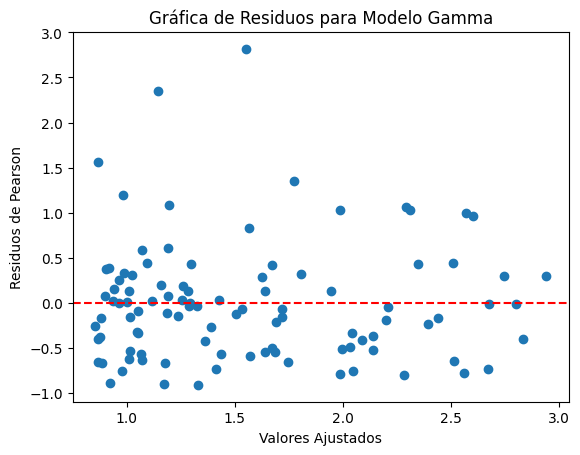

In [ ]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Simulación de datos
np.random.seed(42)
X = np.c_[np.ones(100), np.random.uniform(1, 5, 100)]  # Variable predictora
Y = np.random.gamma(shape=2, scale=2/X[:,1])  # Respuesta con distribución Gamma

# Ajuste del modelo Gamma con función de vínculo inversa
modelo_c = sm.GLM(Y, X, family=sm.families.Gamma()).fit()

# Predicciones del modelo
Y_pred = modelo_c.fittedvalues

# Cálculo de la desviación de Pearson
V_mu = Y_pred ** 2  # Varianza para la distribución Gamma
pearson_residuals = (Y - Y_pred) / np.sqrt(V_mu)
chi2_pearson = np.sum(pearson_residuals**2)

print(modelo.summary())
print(f"Desviación de Pearson: {chi2_pearson:.4f}")

# Gráfica de residuos de Pearson
plt.scatter(Y_pred, pearson_residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Valores Ajustados")
plt.ylabel("Residuos de Pearson")
plt.title("Gráfica de Residuos para Modelo Gamma")
plt.show()

Si $\chi^2$  es grande, el modelo no ajusta bien los datos.

Valores muy altos sugieren que el modelo no captura bien la varianza.

La gráfica de residuos debe mostrar una distribución aleatoria sin patrones claros.

## **2. Prueba de Deviance**
Para modelos de **conteo** (Poisson, Binomial Negativa), la deviance mide cuánto se aleja un modelo del modelo saturado.


In [ ]:
D_stat = -2 * (modelo.llnull - modelo.llf)
p_value_D = 1 - chi2.cdf(D_stat, df)
print(f"Estadístico D: {D_stat:.4f}, p-valor: {p_value_D:.4f}")

Estadístico D: 41.3380, p-valor: 0.0000


Si $p < 0.05$, el modelo ajustado es significativamente diferente del modelo saturado.

## 3. Matriz de Confusión para respuestas discretas

Para modelos con respuesta binaria $\{0,1\}$, evaluamos el ajuste con una matriz de confusión y verificamos un punto de corte para clasificar correctamente las predicciones.

Si el modelo clasifica bien, la diagonal de la matriz de confusión tendrá valores altos.




Para modelos con respuestas **binarias** o **multiclase**, se usan métricas basadas en **matrices de confusión**.

### **3.1. Matriz de Confusión**
Para un modelo con respuesta binaria ($ y \in \{0,1\} $), la matriz de confusión se construye con:

|                | **Predicción: 0** | **Predicción: 1** |
|--------------|----------------|----------------|
| **Real: 0** | Verdaderos Negativos (TN) | Falsos Positivos (FP) |
| **Real: 1** | Falsos Negativos (FN) | Verdaderos Positivos (TP) |

Las métricas derivadas incluyen:
- **Exactitud**: $ (TP + TN) / (TP + TN + FP + FN) $
- **Precisión**: $ TP / (TP + FP) $
- **Sensibilidad (Recall)**: $ TP / (TP + FN) $
- **Especificidad**: $ TN / (TN + FP) $


### **F1-Score**
El **F1-Score** es una métrica que combina precisión y sensibilidad en un solo valor:

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$


El **F1-Score** es útil cuando hay un desbalance de clases y se quiere un balance entre precisión y recall.


---


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Simulación de datos binarios
np.random.seed(42)
X_bin = np.c_[np.ones(100), np.random.normal(0, 1, 100)]
Y_bin = np.random.binomial(1, 1 / (1 + np.exp(-X_bin[:, 1])))  # Generamos respuesta binaria

# Ajuste del modelo logístico
modelo_bin = sm.GLM(Y_bin, X_bin, family=sm.families.Binomial()).fit()
Y_pred_prob = modelo_bin.fittedvalues

# Definir umbral y generar predicciones binarias
threshold = 0.5
Y_pred_bin = (Y_pred_prob >= threshold).astype(int)

# Calcular matriz de confusión
matriz_conf = confusion_matrix(Y_bin, Y_pred_bin)
print("Matriz de Confusión:\n", matriz_conf)
print("\nReporte de Clasificación:\n", classification_report(Y_bin, Y_pred_bin))

Matriz de Confusión:
 [[39 16]
 [21 24]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.65      0.71      0.68        55
           1       0.60      0.53      0.56        45

    accuracy                           0.63       100
   macro avg       0.62      0.62      0.62       100
weighted avg       0.63      0.63      0.63       100



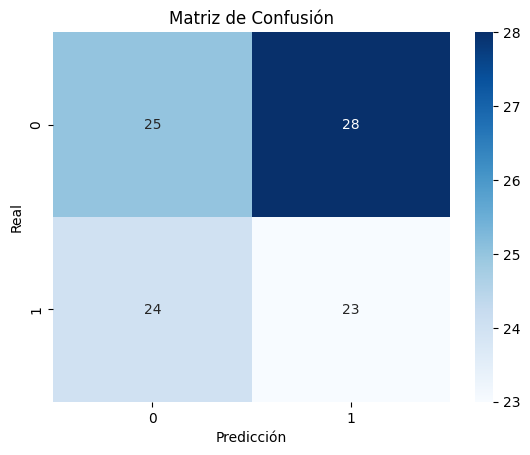

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Simulación de respuestas binarias
np.random.seed(42)
y_real = np.random.binomial(1, 0.5, 100)
y_pred = np.random.binomial(1, 0.5, 100)

# Matriz de confusión
cm = confusion_matrix(y_real, y_pred)

# Visualización
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

## **5. Curva ROC y AUC en MLG**

La **Curva ROC (Receiver Operating Characteristic)** es una herramienta para evaluar el rendimiento de modelos de clasificación, especialmente en modelos de **regresión logística en MLG**.

La curva ROC muestra la tasa de verdaderos positivos (\( TPR \)) frente a la tasa de falsos positivos (\( FPR \)) para diferentes umbrales de clasificación.

### **Fórmulas clave**
- **Tasa de Verdaderos Positivos (Sensibilidad):**
  
  $$
  TPR = \frac{TP}{TP + FN}
  $$
  
- **Tasa de Falsos Positivos:**
  
  $$
  FPR = \frac{FP}{FP + TN}
  $$
  
- **Área Bajo la Curva (AUC, Area Under the Curve):** mide la capacidad del modelo para discriminar entre clases:

$$AUC = \int_{0}^{1} TPR(FPR) \, d(FPR)$$
$$AUC = \sum_{i=1}^{n-1} (FPR_{i+1} - FPR_i) \frac{(TPR_{i+1} + TPR_i)}{2}$$
Esta fórmula discreta se obtiene aplicando la regla del trapecio para aproximar la integral de la curva ROC.


  
  - $ AUC = 1.0 $: Modelo perfecto.
  - $ AUC = 0.5 $: Modelo sin capacidad de discriminación (aleatorio).
  - $ AUC < 0.5 $: Modelo peor que el azar (debería invertirse la predicción).

### **Ejemplo en Python: Cálculo y construcción de la curva ROC**



[       inf 0.96487444 0.92059111 0.91700595 0.90664932 0.90585211
 0.90409583 0.90299733 0.88815453 0.88377011 0.87313072 0.86943492
 0.8655604  0.86555907 0.84615568 0.84590396 0.83979425 0.83842153
 0.82870566 0.82554367 0.81197251 0.80868902 0.78407658 0.77829738
 0.76732694 0.76425434 0.73251171 0.73046209 0.65543087 0.55067763]
[0.         0.         0.         0.07142857 0.07142857 0.14285714
 0.14285714 0.21428571 0.21428571 0.28571429 0.28571429 0.35714286
 0.35714286 0.42857143 0.42857143 0.5        0.5        0.57142857
 0.57142857 0.64285714 0.64285714 0.71428571 0.71428571 0.78571429
 0.78571429 0.85714286 0.85714286 0.92857143 0.92857143 1.        ]


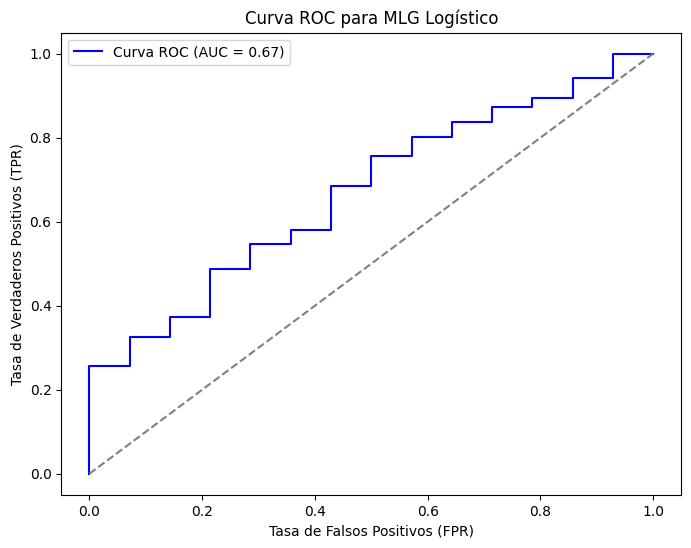

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import statsmodels.api as sm

# Simulación de datos
np.random.seed(42)
X = np.c_[np.ones(100), np.random.normal(2, 1, 100)]
Y = np.random.binomial(1, 1 / (1 + np.exp(-X[:, 1])))

# Ajuste de modelo logístico en MLG
modelo = sm.GLM(Y, X, family=sm.families.Binomial()).fit()
predicciones = modelo.fittedvalues

# Cálculo de la curva ROC
fpr, tpr, thresholds = roc_curve(Y, predicciones)
print(thresholds)
print(fpr)
# prompt: fpr, tpr, thresholds = roc_curve(Y, predicciones) ¿qué son los thresholds en la salida de esa función?

# Los thresholds en la salida de roc_curve son los diferentes umbrales de probabilidad utilizados para clasificar las observaciones.
# Para cada umbral, se calcula el FPR y el TPR.
# Por ejemplo, si el threshold es 0.5, todas las predicciones con probabilidad >= 0.5 serán clasificadas como 1, y las demás como 0.
# La curva ROC se construye graficando los pares (FPR, TPR) para todos los thresholds.
# En resumen, thresholds representa los diferentes puntos de corte utilizados para determinar la clasificación binaria, basándose en las probabilidades de predicción del modelo.
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea aleatoria
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC para MLG Logístico")
plt.legend()
plt.show()


0.6686046511627908


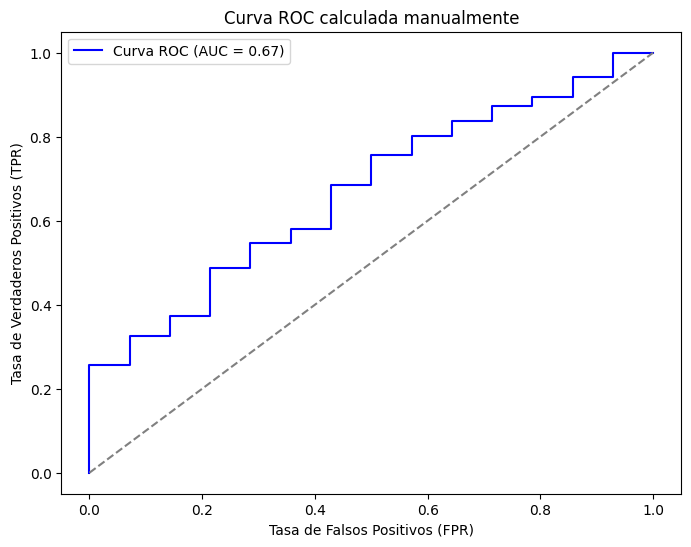

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulación de etiquetas reales y puntuaciones de modelo
# np.random.seed(42)
# Y = np.random.binomial(1, 0.5, 100)  # Etiquetas reales
# scores = np.random.rand(100)  # Puntuaciones del modelo

# # Ordenamos los valores según las puntuaciones del modelo
# thresholds = np.sort(scores)[::-1]
TPR = []
FPR = []

for t in thresholds:
    Y_pred = (predicciones >= t).astype(int)
    TP = np.sum((Y_pred == 1) & (Y == 1))
    FP = np.sum((Y_pred == 1) & (Y == 0))
    FN = np.sum((Y_pred == 0) & (Y == 1))
    TN = np.sum((Y_pred == 0) & (Y == 0))

    TPR.append(TP / (TP + FN))
    FPR.append(FP / (FP + TN))

# Cálculo manual del AUC con la fórmula discreta
auc_manual = np.sum([(FPR[i+1] - FPR[i]) * (TPR[i+1] + TPR[i]) / 2 for i in range(len(FPR)-1)])
print(auc_manual)

# Graficar la curva ROC
plt.figure(figsize=(8,6))
plt.plot(FPR, TPR, color='blue', label=f'Curva ROC (AUC = {auc_manual:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea aleatoria
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC calculada manualmente")
plt.legend()
plt.show()


## **4. Verificación de punto de corte para discretizar las predicciones**

En **modelos logísticos o de clasificación**, la predicción es una probabilidad $ P(y=1 | X) $, y se necesita un **umbral** para convertirla en una clase binaria. El valor estándar es 0.5, pero puede ajustarse según la métrica de interés.

---


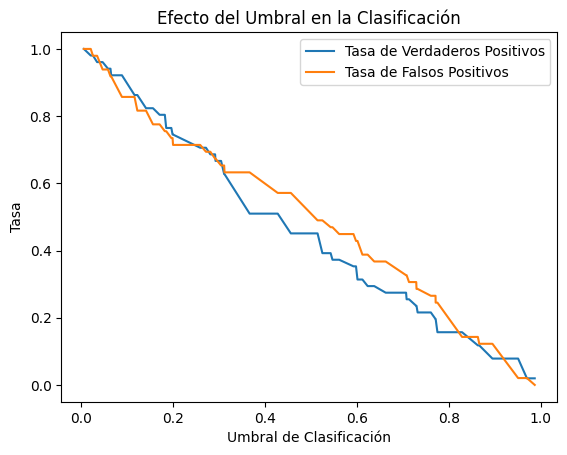

In [ ]:
from sklearn.metrics import roc_curve

# Simulación de probabilidades predichas
np.random.seed(42)
y_scores = np.random.rand(100)
y_real = np.random.binomial(1, 0.5, 100)

# Curva ROC para evaluar diferentes puntos de corte
fpr, tpr, thresholds = roc_curve(y_real, y_scores)
plt.plot(thresholds, tpr, label='Tasa de Verdaderos Positivos')
plt.plot(thresholds, fpr, label='Tasa de Falsos Positivos')
plt.xlabel('Umbral de Clasificación')
plt.ylabel('Tasa')
plt.legend()
plt.title('Efecto del Umbral en la Clasificación')
plt.show()

### **4.1 Verificación Gráfica**

Si bien no es una prueba numérica, una gráfica de residuos nos da información sobre el ajuste.


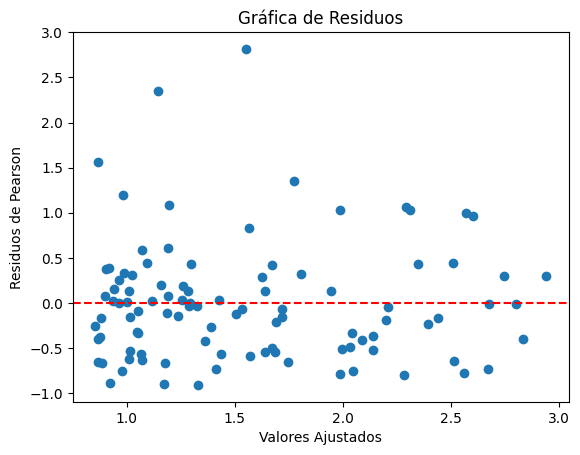

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(modelo_c.fittedvalues, pearson_residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Valores Ajustados")
plt.ylabel("Residuos de Pearson")
plt.title("Gráfica de Residuos")
plt.show()

Si los residuos están aleatoriamente dispersos alrededor de 0, el modelo es adecuado.


## **5. Otras métricas de ajuste para respuestas continuas**

- **Error Cuadrático Medio (MSE)**:
  $$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

- **Error Absoluto Medio (MAE)**:
  $$ MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$

- **Error Porcentual Absoluto Medio (MAPE)**:
  $$ MAPE = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100 $$

- **Coeficiente de determinación (R²)**:
  $$ R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} $$

---


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Cálculo de métricas para regresión
mse = mean_squared_error(y_real, y_pred)
mae = mean_absolute_error(y_real, y_pred)
mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
r2 = r2_score(y_real, y_pred)

print(f"MSE: {mse:.4f}, MAE: {mae:.4f}, MAPE: {mape:.2f}%, R^2: {r2:.4f}")


## **6. Otras métricas de ajuste para respuestas discretas multiclase**

Además de la matriz de confusión, para respuestas **multiclase**, se utilizan métricas como:

- **Precisión Macro/Micro**: Promedian la precisión en todas las clases.
- **Sensibilidad y Especificidad por clase**.
- **F1-Score Macro/Micro**: Promedian la métrica F1 entre clases.

---


In [ ]:
from sklearn.metrics import classification_report

# Simulación de respuestas multiclase
np.random.seed(42)
y_real_multiclass = np.random.randint(0, 3, 100)  # Clases 0, 1, 2
y_pred_multiclass = np.random.randint(0, 3, 100)

# Reporte de métricas
report = classification_report(y_real_multiclass, y_pred_multiclass, output_dict=True)
print(classification_report(y_real_multiclass, y_pred_multiclass))

# Detalle de la salida
df_report = pd.DataFrame(report).transpose()
print(df_report)

### Conclusión

Para evaluar el ajuste de un MLG:

* Para variables continuas, usa la desviación de Pearson.

* Para modelos de conteo, usa la prueba de deviance.

* Para modelos de clasificación, usa la matriz de confusión y la curva ROC.

* Las gráficas de residuos ayudan a diagnosticar problemas visualmente.



#**Hiperparámetros en Modelos Lineales Generalizados (MLG)**

Los **Modelos Lineales Generalizados (MLG)** tienen **hiperparámetros** que deben ser ajustados para mejorar su rendimiento. A diferencia de los coeficientes $ \beta $, que se estiman mediante **máxima verosimilitud**, los hiperparámetros deben seleccionarse con técnicas de validación.

---

## **1. ¿Cuáles son los hiperparámetros en MLG?**
Los hiperparámetros en MLG dependen de la familia de distribución y la función de enlace utilizada. Los más comunes incluyen:

| **Hiperparámetro** | **Descripción** | **Cómo afecta el modelo** |
|---------------------|----------------|------------------------|
| **Función de enlace** $ g(\mu) $ | Transforma la media $ \mu $ en función lineal de los predictores. | Un mal enlace puede generar sesgo en las predicciones. |
| **Parámetro de dispersión $ \phi $** | Controla la variabilidad de los datos para distribuciones como Gamma o Tweedie. | Si es incorrecto, la varianza estimada será errónea. |
| **Parámetro de potencia $ p $** (Tweedie) | Define la relación entre la media y la varianza en distribuciones Tweedie. | Afecta el comportamiento de la distribución entre Poisson y Gamma. |
| **Regularización (L1/L2)** | Penalización sobre los coeficientes $ \beta $ para evitar sobreajuste. | Controla la complejidad del modelo. |

---

## **2. ¿Cómo se identifican los hiperparámetros?**
Los hiperparámetros se ajustan con técnicas como:

- **Validación cruzada (Cross-validation)**: Evalúa el desempeño del modelo en múltiples particiones de los datos.
- **Búsqueda en malla (Grid Search)**: Prueba combinaciones de hiperparámetros en un conjunto predefinido.
- **Optimización Bayesiana**: Ajusta hiperparámetros de manera más eficiente que Grid Search.

Ejemplo de búsqueda en malla para la regularización de un MLG con regresión de Poisson:


In [ ]:

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import PoissonRegressor
import numpy as np

# Simulación de datos
np.random.seed(42)
X = np.random.normal(2, 1, (100, 2))
Y = np.random.poisson(np.exp(0.5 * X[:, 0] + 0.3 * X[:, 1]))

# Definimos los hiperparámetros a evaluar
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10]}  # Regularización L2

# Búsqueda en malla con validación cruzada
search = GridSearchCV(PoissonRegressor(), param_grid, cv=5, scoring='neg_log_loss')
search.fit(X, Y)

print("Mejor hiperparámetro:", search.best_params_)
